
# Triadic Cell Notebook v36
## Direct lookup → shape lookup → no-null potential shift

This notebook implements the three-stage runtime:

1. **Direct lookup**
   - exact stored hit
   - `select * where noun = noun`

2. **Shape lookup**
   - no direct hit, search by geometry
   - `select * distinct where geometry = geometry`

3. **No-null potential shift**
   - if no lawful closure exists, null is not allowed
   - emit a **request shape**
   - pull back only the requested observable slice
   - fold on the returned fit

This is the first notebook in the line that turns the "socket / plug / ping" idea into code.



## Practical meaning

The point is:
- exact hits should be cheap
- shape matches should recover what is not stored as a direct noun/value
- unresolved cases should not return null
- instead they should enter a request-shaped pull loop

Main outputs:
- `compare_summary`
- `by_mode_compare`
- `potential_summary`
- `stage_mix`
- `request_trace_df`


In [1]:

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)

print("Environment ready.")


Environment ready.



## Canonical triadic chain


In [2]:

n_classes = 4
dim = 6

base_molds = np.array([
    [
        [0.95, 0.15, 0.10, 0.20, 0.30, 0.10],
        [0.70, 0.25, 0.45, 0.30, 0.45, 0.20],
        [0.55, 0.20, 0.60, 0.25, 0.70, 0.35],
    ],
    [
        [0.10, 0.95, 0.15, 0.25, 0.10, 0.30],
        [0.25, 0.72, 0.25, 0.50, 0.25, 0.45],
        [0.20, 0.58, 0.30, 0.70, 0.30, 0.72],
    ],
    [
        [0.20, 0.10, 0.95, 0.15, 0.25, 0.12],
        [0.45, 0.25, 0.75, 0.30, 0.42, 0.22],
        [0.62, 0.22, 0.55, 0.25, 0.72, 0.30],
    ],
    [
        [0.15, 0.22, 0.18, 0.95, 0.12, 0.35],
        [0.28, 0.42, 0.25, 0.75, 0.22, 0.58],
        [0.35, 0.72, 0.30, 0.60, 0.25, 0.78],
    ],
], dtype=float)

def normalize01(x):
    return np.clip(x, 0.0, 1.0)

def cosine_similarity(a, b):
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))

def chain_mix(prev_shape, local_mold, alpha=0.58):
    return normalize01(alpha * prev_shape + (1.0 - alpha) * local_mold)

def build_chain_for_class(cls):
    s0 = normalize01(base_molds[cls, 0].copy())
    s1 = chain_mix(s0, base_molds[cls, 1], alpha=0.58)
    s2 = chain_mix(s1, base_molds[cls, 2], alpha=0.58)
    return [s0, s1, s2]

chains = {cls: build_chain_for_class(cls) for cls in range(n_classes)}
pd.DataFrame(chains[0], index=["shape", "bridge_value", "declared_value"])


,0,1,2,3,4,5
shape,0.9500,0.15000,0.10000,0.20000,0.30000,0.10000
bridge_value,0.8450,0.19200,0.24700,0.24200,0.36300,0.14200
declared_value,0.7211,0.19536,0.39526,0.24536,0.50454,0.22936



## Directional basis


In [3]:

raw_basis = np.array([
    [1.0, 0.0, 0.6, 0.2, 0.0, 0.3],
    [0.2, 1.0, 0.0, 0.6, 0.2, 0.0],
    [0.0, 0.2, 1.0, 0.0, 0.6, 0.2],
    [0.6, 0.0, 0.2, 1.0, 0.0, 0.6],
    [0.0, 0.6, 0.2, 0.0, 1.0, 0.2],
], dtype=float)

basis = []
for v in raw_basis:
    u = v.copy()
    for b in basis:
        u = u - np.dot(u, b) * b
    n = np.linalg.norm(u)
    if n > 1e-8:
        basis.append(u / n)

U = np.stack(basis, axis=0)
U.shape


(5, 6)


## Query corruption


In [4]:

QUERY_MODES = ["existing", "partial", "noisy", "ambiguous", "inverse_hint"]
QUERY_WEIGHTS = np.array([0.28, 0.28, 0.18, 0.16, 0.10], dtype=float)
QUERY_WEIGHTS = QUERY_WEIGHTS / QUERY_WEIGHTS.sum()

def make_query(cls, mode):
    target = chains[cls][0].copy()
    q = target.copy()

    if mode == "existing":
        q += rng.normal(0.0, 0.015, size=q.shape[0])
    elif mode == "partial":
        mask = rng.random(q.shape[0]) < 0.45
        q[mask] = 0.0
        q += rng.normal(0.0, 0.02, size=q.shape[0])
    elif mode == "noisy":
        q += rng.normal(0.0, 0.08, size=q.shape[0])
    elif mode == "ambiguous":
        alt = int((cls + rng.integers(1, n_classes)) % n_classes)
        q = 0.56 * target + 0.44 * chains[alt][0] + rng.normal(0.0, 0.03, size=q.shape[0])
    elif mode == "inverse_hint":
        inv = 1.0 - target
        q = 0.65 * target + 0.35 * inv + rng.normal(0.0, 0.03, size=q.shape[0])
        mask = rng.random(q.shape[0]) < 0.20
        q[mask] = 0.0

    return normalize01(q)



## Core fold decomposition


In [5]:

def directional_coeffs(x):
    return U @ x

def reconstruct_from_coeffs(c):
    return np.clip(c @ U, 0.0, 1.0)

def pythagorean_split(query, target):
    aq = directional_coeffs(query)
    at = directional_coeffs(target)

    aligned = np.minimum(aq, at)
    missing = np.maximum(at - aq, 0.0)
    excess = np.maximum(aq - at, 0.0)

    R = reconstruct_from_coeffs(aligned)
    M = reconstruct_from_coeffs(missing)
    E = reconstruct_from_coeffs(excess)

    aligned_energy = float(np.sum(aligned ** 2))
    missing_energy = float(np.sum(missing ** 2))
    excess_energy = float(np.sum(excess ** 2))
    total_energy = float(np.sum(at ** 2) + 1e-8)

    return {
        "R": R,
        "M": M,
        "E": E,
        "aligned_ratio": float(aligned_energy / total_energy),
        "missing_ratio": float(missing_energy / total_energy),
        "excess_ratio": float(excess_energy / total_energy),
    }



## Candidate evaluation and field emission


In [6]:

def triadic_evaluate(query, cls):
    s0, s1, s2 = chains[cls]
    retrieve_fit = cosine_similarity(query, s0)
    split = pythagorean_split(query, s0)

    folded0 = normalize01(query + split["M"] - 0.25 * split["E"])
    projected1 = chain_mix(folded0, base_molds[cls, 1], alpha=0.58)
    projected2 = chain_mix(projected1, base_molds[cls, 2], alpha=0.58)

    bridge_energy = (
        0.35 * split["missing_ratio"]
        + 0.20 * split["excess_ratio"]
        + 0.45 * (1.0 - retrieve_fit)
    )

    declaration_score = (
        0.60 * retrieve_fit
        + 0.35 * split["aligned_ratio"]
        - 0.95 * split["missing_ratio"]
        - 0.45 * split["excess_ratio"]
        - 0.45 * bridge_energy
    )

    return {
        "class": cls,
        "retrieve_fit": float(retrieve_fit),
        "bridge_energy": float(bridge_energy),
        "declaration_score": float(declaration_score),
        "R": split["R"],
        "M": split["M"],
        "E": split["E"],
        "missing_ratio": split["missing_ratio"],
        "excess_ratio": split["excess_ratio"],
        "declared_value": projected2,
    }

def triadic_query(query):
    results = [triadic_evaluate(query, cls) for cls in range(n_classes)]
    results = sorted(results, key=lambda r: r["declaration_score"], reverse=True)
    best = results[0]
    second = results[1]
    margin = float(best["declaration_score"] - second["declaration_score"])
    return best, results, margin

def produce_fields_for_class(query, cls):
    ev = triadic_evaluate(query, cls)
    all_results = [triadic_evaluate(query, c) for c in range(n_classes)]
    all_results = sorted(all_results, key=lambda r: r["declaration_score"], reverse=True)

    if ev["class"] == all_results[0]["class"]:
        margin = float(ev["declaration_score"] - all_results[1]["declaration_score"])
    else:
        margin = float(ev["declaration_score"] - all_results[0]["declaration_score"])

    retrieve_mask = normalize01(ev["R"])
    missing_mask = normalize01(ev["M"])
    contradiction_mask = normalize01(ev["E"])
    signed_correction = ev["M"] - 0.6 * ev["E"]

    total = retrieve_mask + missing_mask + 1e-8
    retrieve_mask = retrieve_mask / total
    missing_mask = missing_mask / total

    return {
        "predicted_class": cls,
        "margin": margin,
        "retrieve_fit": ev["retrieve_fit"],
        "bridge_energy": ev["bridge_energy"],
        "declaration_score": ev["declaration_score"],
        "retrieve_mask": retrieve_mask,
        "missing_mask": missing_mask,
        "contradiction_mask": contradiction_mask,
        "signed_correction": signed_correction,
        "declared_value": ev["declared_value"],
    }

def produce_fields_best(query):
    best, _, _ = triadic_query(query)
    return produce_fields_for_class(query, best["class"])



## Observable map and request shape


In [7]:

obs_dim = 3

OBS_W = np.array([
    [0.80, 0.10, 0.35, 0.05, 0.20, 0.10],
    [0.10, 0.75, 0.10, 0.30, 0.05, 0.25],
    [0.20, 0.10, 0.55, 0.10, 0.45, 0.20],
], dtype=float)

def observable_from_declared(declared_value):
    o = OBS_W @ declared_value
    return normalize01(o)

def build_request_shape(fields, top_k=1):
    pred_obs = observable_from_declared(fields["declared_value"])
    missing_strength = float(fields["missing_mask"].mean())
    contradiction_strength = float(fields["contradiction_mask"].mean())

    request_scores = (1.0 - pred_obs) * (0.7 * missing_strength + 0.3 * contradiction_strength)
    idx = np.argsort(request_scores)[-top_k:]

    mask = np.zeros(obs_dim, dtype=float)
    mask[idx] = 1.0

    tolerance = 0.10 + 0.25 * contradiction_strength
    priority = 0.7 * missing_strength + 0.3 * contradiction_strength

    return {
        "mask": mask,
        "expected_profile": pred_obs,
        "tolerance": float(tolerance),
        "priority": float(priority),
    }

def provider_pull(true_cls, request_shape):
    full_obs = observable_from_declared(chains[true_cls][2])
    mask = request_shape["mask"]
    packet = full_obs * mask + rng.normal(0.0, 0.02, size=full_obs.shape[0]) * mask
    return normalize01(packet)



## Three-stage runtime


In [8]:

DIRECT_THRESHOLD = 0.985
SHAPE_THRESHOLD = 0.78

def direct_lookup(query):
    scores = [(cls, cosine_similarity(query, chains[cls][0])) for cls in range(n_classes)]
    scores.sort(key=lambda x: x[1], reverse=True)
    cls, score = scores[0]
    return {"hit": score >= DIRECT_THRESHOLD, "class": cls, "score": float(score)}

def shape_lookup(query):
    best, results, margin = triadic_query(query)
    return {
        "hit": best["retrieve_fit"] >= SHAPE_THRESHOLD,
        "class": best["class"],
        "score": float(best["retrieve_fit"]),
        "margin": float(margin),
    }

def no_null_potential_shift(query, true_cls, max_cycles=4, beam_width=3, exhale_steps=2, step_size=0.45, damping=0.85):
    init = sorted(
        [(cls, triadic_evaluate(query, cls)["declaration_score"]) for cls in range(n_classes)],
        key=lambda x: x[1],
        reverse=True
    )[:beam_width]
    beam = [{"cls": cls, "query": query.copy(), "spawn_from": -1} for cls, _ in init]
    trace_rows = []

    for cycle in range(max_cycles):
        expanded = []
        for branch in beam:
            q = branch["query"].copy()
            cls = branch["cls"]

            for _ in range(exhale_steps):
                f = produce_fields_for_class(q, cls)
                request = build_request_shape(f, top_k=1)
                packet = provider_pull(true_cls, request)

                packet_back = normalize01(request["mask"] @ OBS_W)
                update = step_size * (0.7 * f["signed_correction"] + 0.3 * packet_back)
                q = normalize01(damping * q + (1.0 - damping) * normalize01(q + update))

            expanded.append({"cls": cls, "query": q.copy(), "spawn_from": branch["spawn_from"]})

            alt = sorted(
                [(c, triadic_evaluate(q, c)["declaration_score"]) for c in range(n_classes)],
                key=lambda x: x[1],
                reverse=True
            )[:2]
            for alt_cls, _ in alt:
                if alt_cls != cls:
                    expanded.append({"cls": alt_cls, "query": q.copy(), "spawn_from": cls})

        scored = []
        for item in expanded:
            fields = produce_fields_for_class(item["query"], item["cls"])
            request = build_request_shape(fields, top_k=1)
            packet = provider_pull(true_cls, request)
            pred_obs = observable_from_declared(fields["declared_value"])
            obs_misfit = float(np.mean(np.abs(request["mask"] * (packet - pred_obs))))

            energy = (
                0.90 * float(fields["missing_mask"].mean())
                + 0.50 * float(fields["contradiction_mask"].mean())
                - 0.70 * float(fields["declaration_score"])
                - 0.25 * float(fields["retrieve_mask"].mean())
                + 0.80 * obs_misfit
            )

            scored.append({
                **item,
                "energy": float(energy),
                "missing_mass": float(fields["missing_mask"].mean()),
                "retrieve_mass": float(fields["retrieve_mask"].mean()),
                "declaration_score": float(fields["declaration_score"]),
                "obs_misfit": obs_misfit,
                "request_mask_0": float(request["mask"][0]),
                "request_mask_1": float(request["mask"][1]),
                "request_mask_2": float(request["mask"][2]),
                "obs_packet_0": float(packet[0]),
                "obs_packet_1": float(packet[1]),
                "obs_packet_2": float(packet[2]),
            })

        best_per_class = {}
        for item in scored:
            cls = item["cls"]
            if cls not in best_per_class or item["energy"] < best_per_class[cls]["energy"]:
                best_per_class[cls] = item

        beam = sorted(best_per_class.values(), key=lambda x: x["energy"])[:beam_width]

        for rank, item in enumerate(beam):
            trace_rows.append({
                "cycle": cycle,
                "beam_rank": rank,
                "class": item["cls"],
                "energy": item["energy"],
                "missing_mass": item["missing_mass"],
                "retrieve_mass": item["retrieve_mass"],
                "declaration_score": item["declaration_score"],
                "obs_misfit": item["obs_misfit"],
                "request_mask_0": item["request_mask_0"],
                "request_mask_1": item["request_mask_1"],
                "request_mask_2": item["request_mask_2"],
                "obs_packet_0": item["obs_packet_0"],
                "obs_packet_1": item["obs_packet_1"],
                "obs_packet_2": item["obs_packet_2"],
                "spawn_from": item["spawn_from"],
            })

    final_best = beam[0]
    final_fields = produce_fields_for_class(final_best["query"], final_best["cls"])
    return final_best["query"], pd.DataFrame(trace_rows), final_fields

def three_stage_runtime(query, true_cls):
    s1 = direct_lookup(query)
    if s1["hit"]:
        fields = produce_fields_for_class(query, s1["class"])
        return {
            "stage": "direct_lookup",
            "predicted_class": s1["class"],
            "score": s1["score"],
            "trace_df": pd.DataFrame(),
            "fields": fields,
        }

    s2 = shape_lookup(query)
    if s2["hit"]:
        fields = produce_fields_for_class(query, s2["class"])
        return {
            "stage": "shape_lookup",
            "predicted_class": s2["class"],
            "score": s2["score"],
            "trace_df": pd.DataFrame(),
            "fields": fields,
        }

    q_final, trace_df, fields = no_null_potential_shift(query, true_cls=true_cls)
    return {
        "stage": "potential_shift",
        "predicted_class": fields["predicted_class"],
        "score": float(fields["declaration_score"]),
        "trace_df": trace_df,
        "fields": fields,
    }



## Single example


In [9]:

example_cls = 1
example_mode = "partial"
q0 = make_query(example_cls, example_mode)

result = three_stage_runtime(q0, true_cls=example_cls)
request_trace_df = result["trace_df"]

single_example = pd.DataFrame([{
    "true_class": example_cls,
    "query_mode": example_mode,
    "resolved_stage": result["stage"],
    "predicted_class": result["predicted_class"],
    "retrieve_mass": float(result["fields"]["retrieve_mask"].mean()),
    "missing_mass": float(result["fields"]["missing_mask"].mean()),
    "declaration_score": float(result["fields"]["declaration_score"]),
    "trace_steps": int(len(request_trace_df)),
}])
single_example


,true_class,query_mode,resolved_stage,predicted_class,retrieve_mass,missing_mass,declaration_score,trace_steps
0,1,partial,shape_lookup,3,0.427425,0.572575,-0.009204,0


In [10]:

request_trace_df.head(12)


""



## Baseline compare


In [11]:

rows_compare = []

for true_cls in range(n_classes):
    for _ in range(350):
        mode = rng.choice(QUERY_MODES, p=QUERY_WEIGHTS)
        q = make_query(true_cls, mode)

        first = produce_fields_best(q)
        staged = three_stage_runtime(q, true_cls=true_cls)

        rows_compare.append({
            "true_class": true_cls,
            "query_mode": mode,
            "first_correct": int(first["predicted_class"] == true_cls),
            "staged_correct": int(staged["predicted_class"] == true_cls),
            "first_missing_mass": float(first["missing_mask"].mean()),
            "staged_missing_mass": float(staged["fields"]["missing_mask"].mean()),
            "first_retrieve_mass": float(first["retrieve_mask"].mean()),
            "staged_retrieve_mass": float(staged["fields"]["retrieve_mask"].mean()),
            "resolved_stage": staged["stage"],
        })

compare_df = pd.DataFrame(rows_compare)
compare_df.head()


,true_class,query_mode,first_correct,staged_correct,first_missing_mass,staged_missing_mass,first_retrieve_mass,staged_retrieve_mass,resolved_stage
0,0,noisy,1,1,0.183348,0.183348,0.816652,0.816652,direct_lookup
1,0,noisy,1,1,0.130352,0.130352,0.869648,0.869648,direct_lookup
2,0,partial,0,0,0.809827,0.396866,0.190173,0.603134,potential_shift
3,0,existing,1,1,0.024110,0.024110,0.975890,0.975890,direct_lookup
4,0,noisy,1,1,0.156675,0.156675,0.843325,0.843325,direct_lookup



## Core comparison


In [12]:

compare_summary = pd.DataFrame([{
    "first_pass_accuracy": float(compare_df["first_correct"].mean()),
    "three_stage_accuracy": float(compare_df["staged_correct"].mean()),
    "first_pass_missing_mass": float(compare_df["first_missing_mass"].mean()),
    "three_stage_missing_mass": float(compare_df["staged_missing_mass"].mean()),
    "direct_fraction": float((compare_df["resolved_stage"] == "direct_lookup").mean()),
    "shape_fraction": float((compare_df["resolved_stage"] == "shape_lookup").mean()),
    "potential_fraction": float((compare_df["resolved_stage"] == "potential_shift").mean()),
}])
compare_summary


,first_pass_accuracy,three_stage_accuracy,first_pass_missing_mass,three_stage_missing_mass,direct_fraction,shape_fraction,potential_fraction
0,0.849286,0.853571,0.281453,0.257097,0.436429,0.490714,0.072857


In [13]:

by_mode_compare = (
    compare_df.groupby("query_mode")[[
        "first_correct",
        "staged_correct",
        "first_missing_mass",
        "staged_missing_mass",
        "first_retrieve_mass",
        "staged_retrieve_mass",
    ]]
    .mean()
    .reset_index()
)

by_mode_compare["accuracy_gain"] = by_mode_compare["staged_correct"] - by_mode_compare["first_correct"]
by_mode_compare["missing_drop"] = by_mode_compare["first_missing_mass"] - by_mode_compare["staged_missing_mass"]

by_mode_compare = by_mode_compare.sort_values("accuracy_gain", ascending=False)
by_mode_compare


,query_mode,first_correct,staged_correct,first_missing_mass,staged_missing_mass,first_retrieve_mass,staged_retrieve_mass,accuracy_gain,missing_drop
4,partial,0.559278,0.572165,0.569692,0.491851,0.430307,0.508149,0.012887,0.077841
2,inverse_hint,0.764228,0.772358,0.271739,0.240058,0.716065,0.747746,0.008130,0.031681
0,ambiguous,0.951542,0.951542,0.291686,0.291686,0.698769,0.698769,0.000000,0.000000
1,existing,1.000000,1.000000,0.065180,0.065180,0.931844,0.931844,0.000000,0.000000
3,noisy,1.000000,1.000000,0.177063,0.177063,0.819851,0.819851,0.000000,0.000000



## Potential-only focus


In [14]:

potential_df = compare_df[compare_df["resolved_stage"] == "potential_shift"].copy()

potential_summary = pd.DataFrame([{
    "potential_fraction": float(len(potential_df) / len(compare_df)),
    "potential_accuracy": float(potential_df["staged_correct"].mean()) if len(potential_df) else np.nan,
    "potential_missing_mass": float(potential_df["staged_missing_mass"].mean()) if len(potential_df) else np.nan,
    "potential_retrieve_mass": float(potential_df["staged_retrieve_mass"].mean()) if len(potential_df) else np.nan,
}])
potential_summary


,potential_fraction,potential_accuracy,potential_missing_mass,potential_retrieve_mass
0,0.072857,0.107843,0.330992,0.667374


In [15]:

stage_mix = (
    compare_df.groupby(["query_mode", "resolved_stage"])
    .size()
    .reset_index(name="count")
)
stage_mix["fraction_within_mode"] = (
    stage_mix["count"] /
    stage_mix.groupby("query_mode")["count"].transform("sum")
)
stage_mix


,query_mode,resolved_stage,count,fraction_within_mode
0,ambiguous,shape_lookup,227,1.000000
1,existing,direct_lookup,392,1.000000
2,inverse_hint,potential_shift,26,0.211382
3,inverse_hint,shape_lookup,97,0.788618
4,noisy,direct_lookup,177,0.655556
5,noisy,shape_lookup,93,0.344444
6,partial,direct_lookup,42,0.108247
7,partial,potential_shift,76,0.195876
8,partial,shape_lookup,270,0.695876



## Visual readout


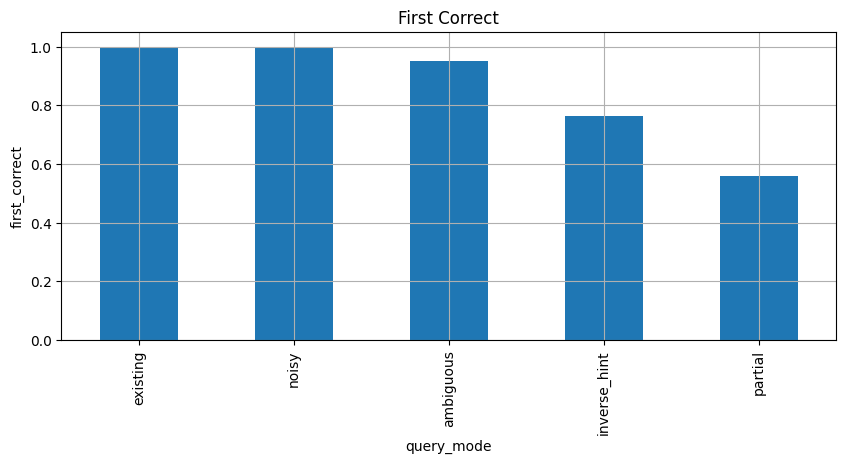

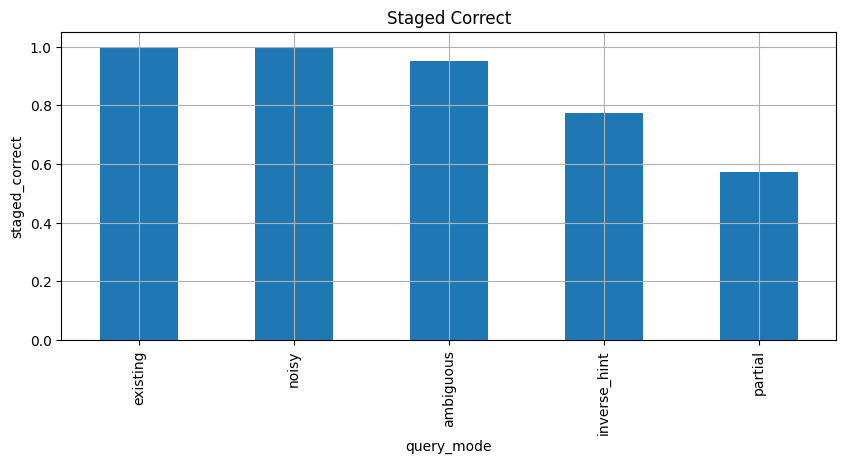

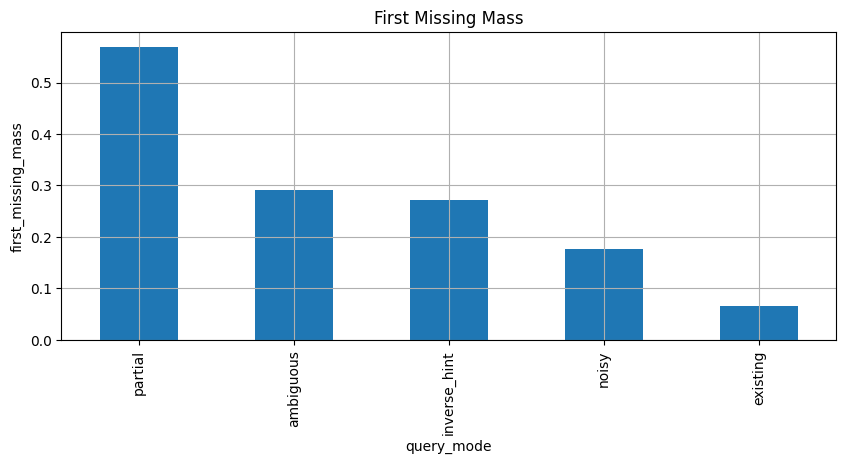

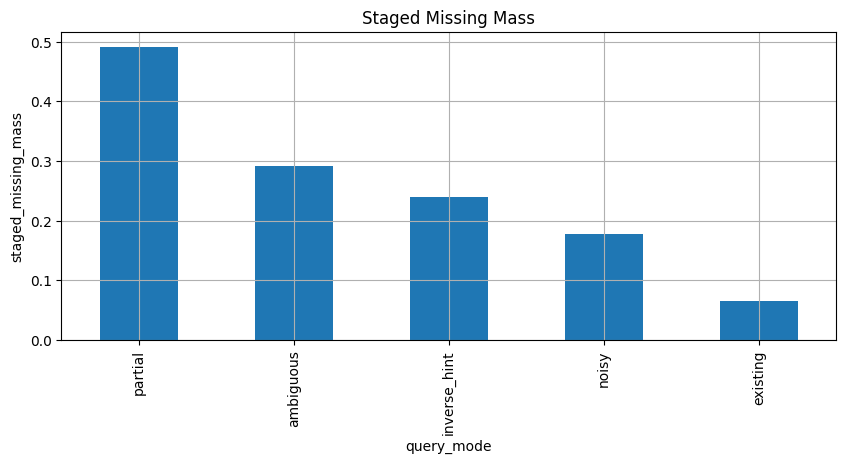

In [16]:

metrics = ["first_correct", "staged_correct", "first_missing_mass", "staged_missing_mass"]

for metric in metrics:
    plt.figure(figsize=(10, 4))
    grouped = compare_df.groupby("query_mode")[metric].mean().sort_values(ascending=False)
    grouped.plot(kind="bar")
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("query_mode")
    plt.ylabel(metric)
    plt.show()


In [17]:

if len(request_trace_df):
    plt.figure(figsize=(10, 4))
    for cls in sorted(request_trace_df["class"].unique()):
        df = request_trace_df[request_trace_df["class"] == cls]
        plt.plot(df["cycle"], df["energy"], marker="o", label=f"class {cls}")
    plt.title("Request-Shape Pull Energy by Cycle")
    plt.xlabel("cycle")
    plt.ylabel("energy")
    plt.legend()
    plt.show()



## Practical readout

This notebook tests the three-stage law directly:

1. direct lookup
2. shape lookup
3. no-null potential shift through request-shaped pull observables

The first tables to read are:

- `compare_summary`
- `by_mode_compare`
- `potential_summary`
- `stage_mix`
- `request_trace_df`
